# MNIST MLP Training Analysis

Visualizzazione dei risultati del training del MLP su MNIST.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
PROJECT_ROOT = os.getenv('PROJECT_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.insert(0, PROJECT_ROOT)
from mlp.data import MNISTLoader
from mlp.network import MLP
from mlp.layer import DenseLayer
from mlp.activations import relu, relu_derivative, softmax
import pickle

# Set matplotlib style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [2]:
# Load training results
try:
    train_losses = np.load(os.path.join(PROJECT_ROOT, 'data', 'train_losses.npy'))
    test_accuracies = np.load(os.path.join(PROJECT_ROOT, 'data', 'test_accuracies.npy'))
    test_losses = np.load(os.path.join(PROJECT_ROOT, 'data', 'test_losses.npy'))
    print("✓ Training results loaded successfully")
except FileNotFoundError:
    print("✗ Training results not found. Run train.py first.")
    train_losses = test_accuracies = test_losses = None

✓ Training results loaded successfully


In [3]:
# Load trained model
def load_model():
    try:
        with open(os.path.join(PROJECT_ROOT, 'data', 'model_weights.pkl'), 'rb') as f:
            weights = pickle.load(f)
        
        model = MLP()
        model.add_layer(DenseLayer(
            input_size=784,
            output_size=256,
            activation_fn=relu,
            activation_derivative=relu_derivative
        ))
        model.add_layer(DenseLayer(
            input_size=256,
            output_size=128,
            activation_fn=relu,
            activation_derivative=relu_derivative
        ))
        model.add_layer(DenseLayer(
            input_size=128,
            output_size=64,
            activation_fn=relu,
            activation_derivative=relu_derivative
        ))
        model.add_layer(DenseLayer(
            input_size=64,
            output_size=10,
            activation_fn=None,
            activation_derivative=None
        ))
        model.set_weights(weights)
        
        print("✓ Model loaded successfully")
        return model
    except FileNotFoundError:
        print("✗ Model weights not found. Run train.py first.")
        return None

model = load_model()

✓ Model loaded successfully


In [4]:
# Load MNIST data for analysis
loader = MNISTLoader(use_keras=True)
x_test, y_test = loader.get_test_data()
x_train, y_train = loader.get_train_data()

print(f"Dataset loaded: {x_train.shape[0]} train, {x_test.shape[0]} test samples")

I0000 00:00:1781300617.816475   10740 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781300619.267707   10740 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781300622.557959   10740 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Dataset loaded: 60000 train, 10000 test samples


## Training Convergence

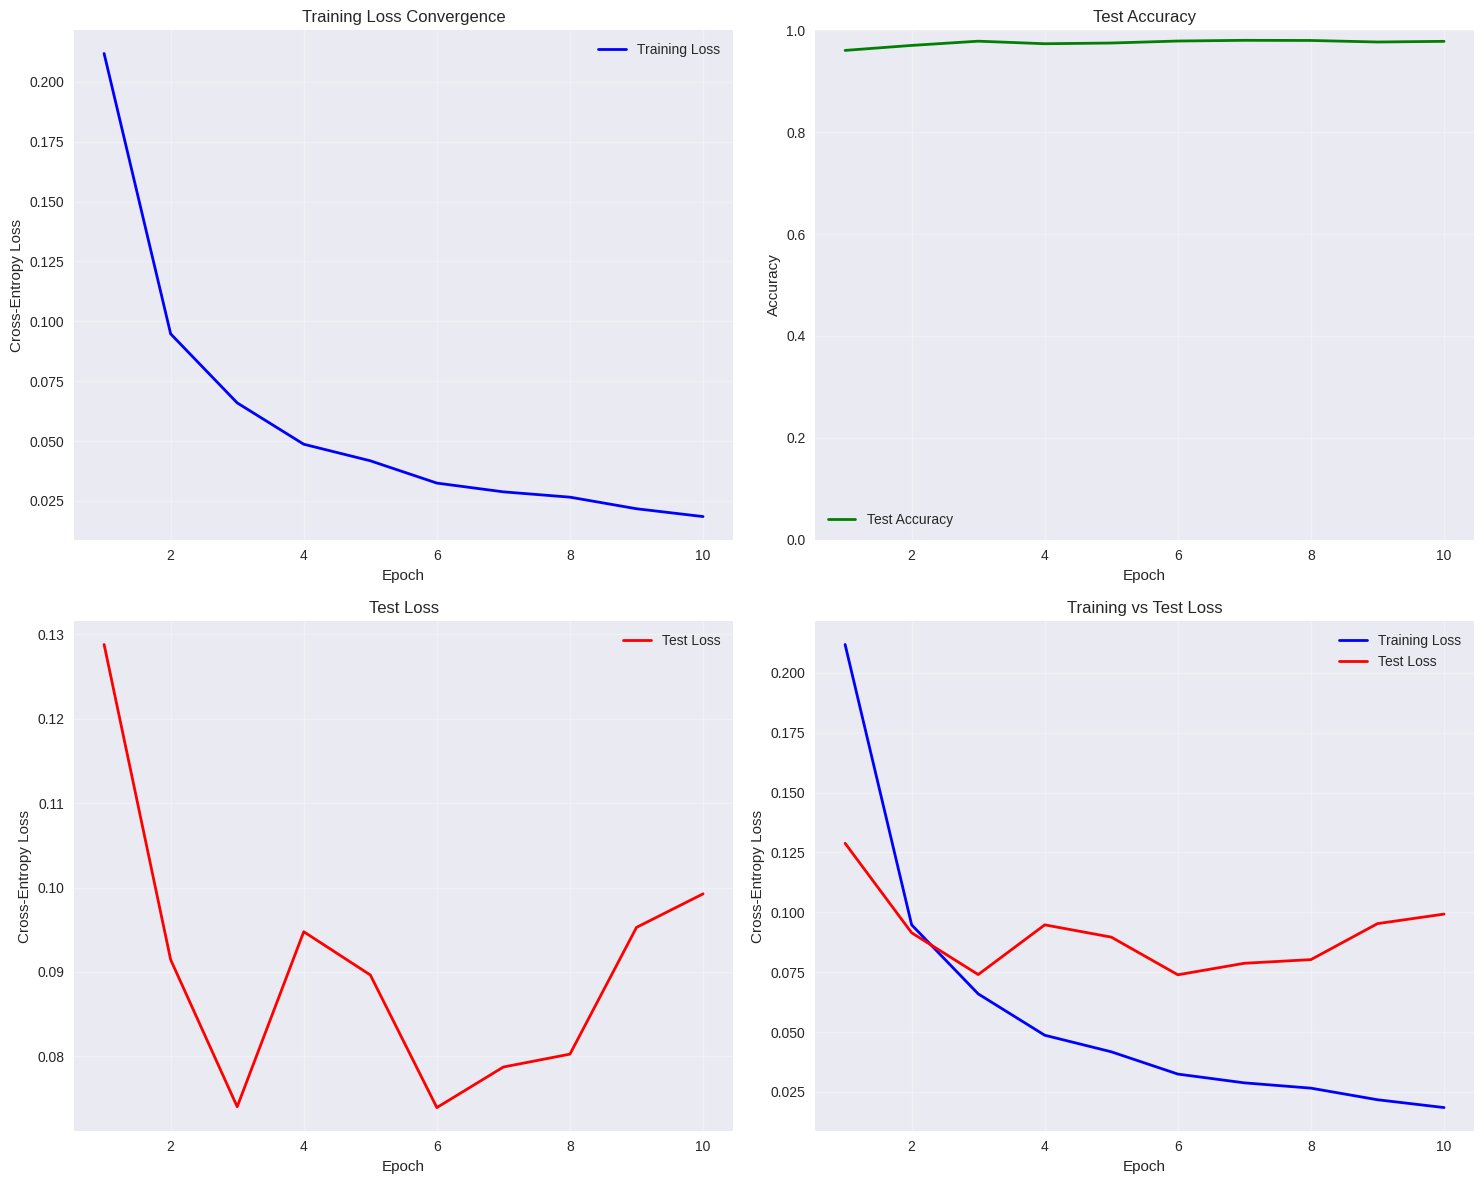

Final Training Loss: 0.018491
Final Test Accuracy: 0.9784 (97.8%)
Best Test Accuracy: 0.9804 (98.0%)


In [5]:
if train_losses is not None:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    epochs = np.arange(1, len(train_losses) + 1)
    
    # Training Loss
    ax1.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.set_title('Training Loss Convergence')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Test Accuracy
    ax2.plot(epochs, test_accuracies, 'g-', linewidth=2, label='Test Accuracy')
    ax2.set_title('Test Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim(0, 1)
    
    # Test Loss
    ax3.plot(epochs, test_losses, 'r-', linewidth=2, label='Test Loss')
    ax3.set_title('Test Loss')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Cross-Entropy Loss')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Combined Loss
    ax4.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
    ax4.plot(epochs, test_losses, 'r-', linewidth=2, label='Test Loss')
    ax4.set_title('Training vs Test Loss')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Cross-Entropy Loss')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Test Accuracy: {test_accuracies[-1]:.4f} ({test_accuracies[-1]*100:.1f}%)")
    print(f"Best Test Accuracy: {max(test_accuracies):.4f} ({max(test_accuracies)*100:.1f}%)")
else:
    print("No training data available")

## Model Analysis

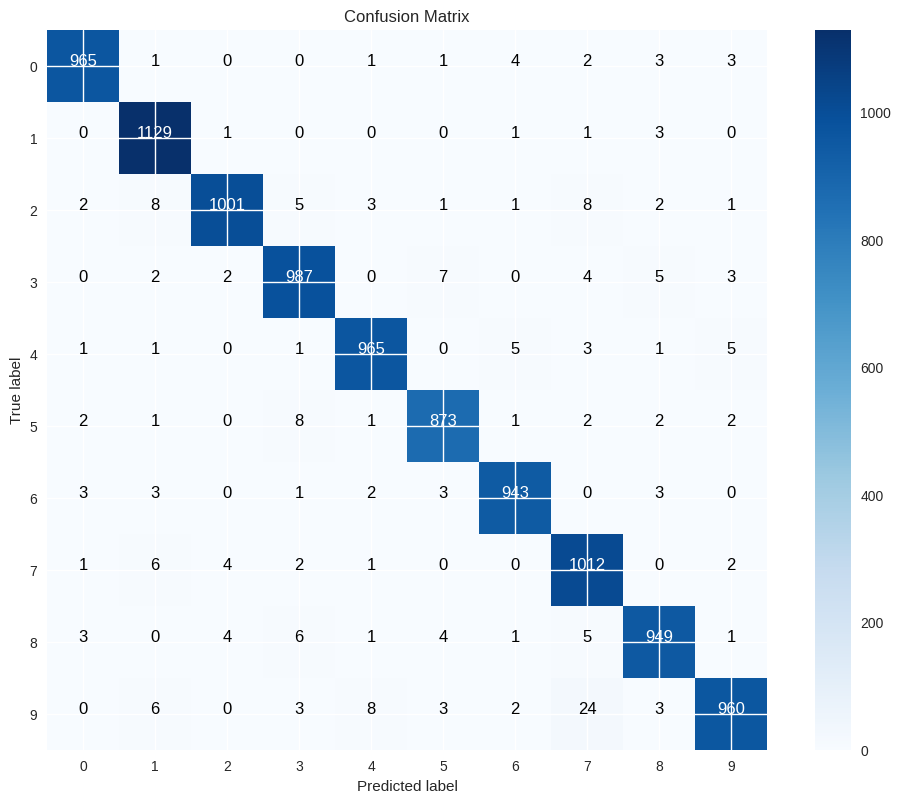

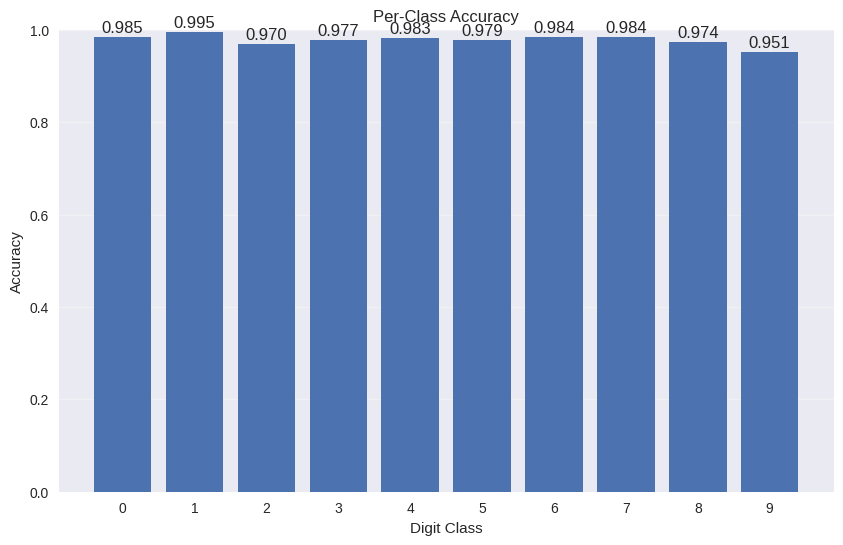

In [6]:
if model is not None:
    # Get predictions
    y_pred_logits = model.forward(x_test)
    y_pred_proba = softmax(y_pred_logits)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Confusion Matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()
    
    classes = [str(i) for i in range(10)]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    
    # Per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    plt.figure(figsize=(10, 6))
    plt.bar(range(10), class_accuracy)
    plt.title('Per-Class Accuracy')
    plt.xlabel('Digit Class')
    plt.ylabel('Accuracy')
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    
    for i, acc in enumerate(class_accuracy):
        plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center')
    
    plt.show()
else:
    print("No model available for analysis")

## Sample Predictions

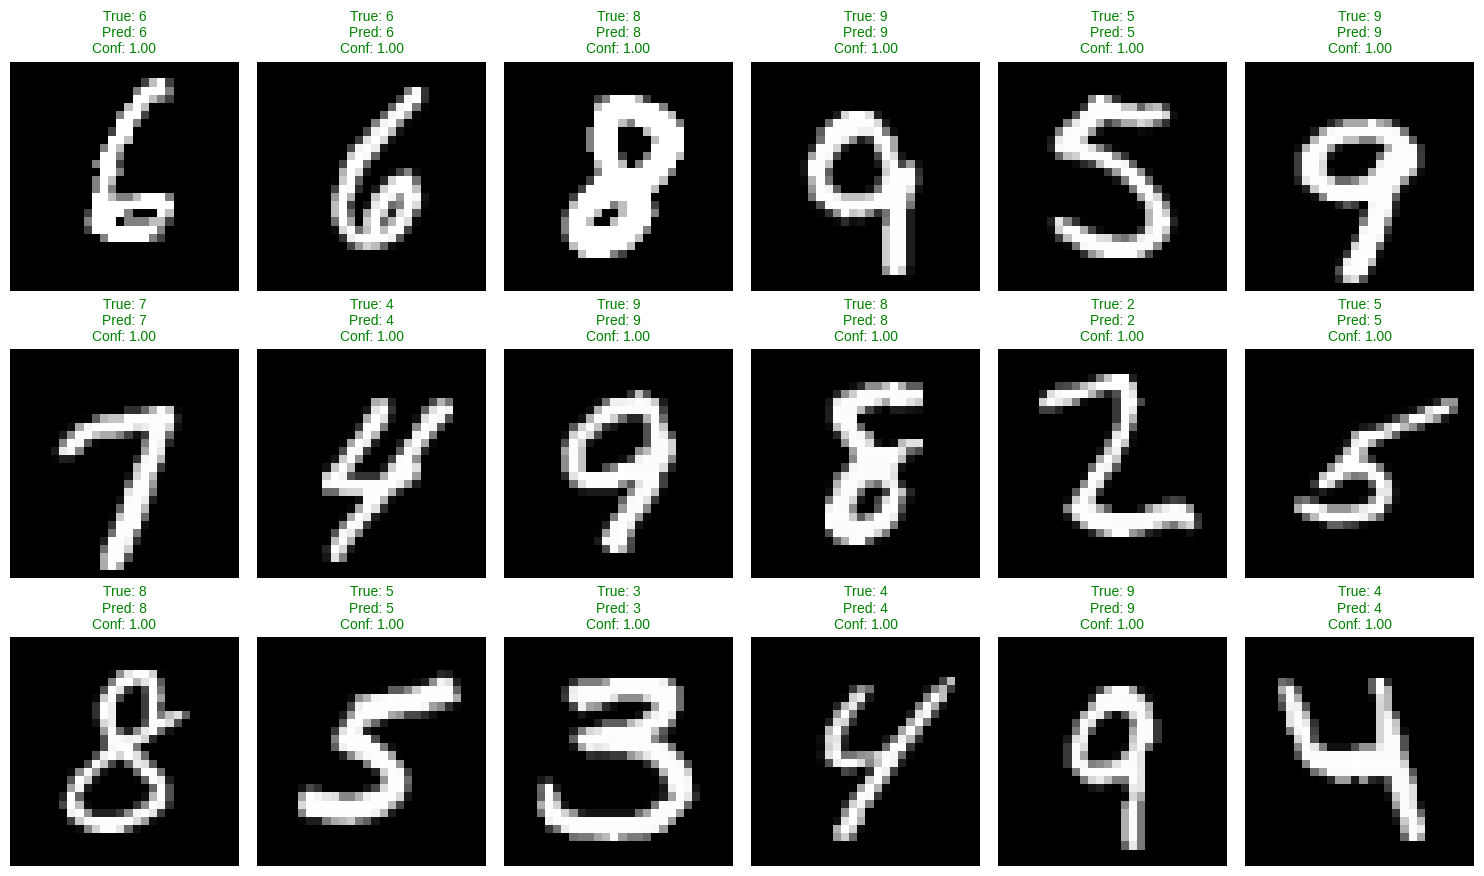


Showing 6 wrong predictions:


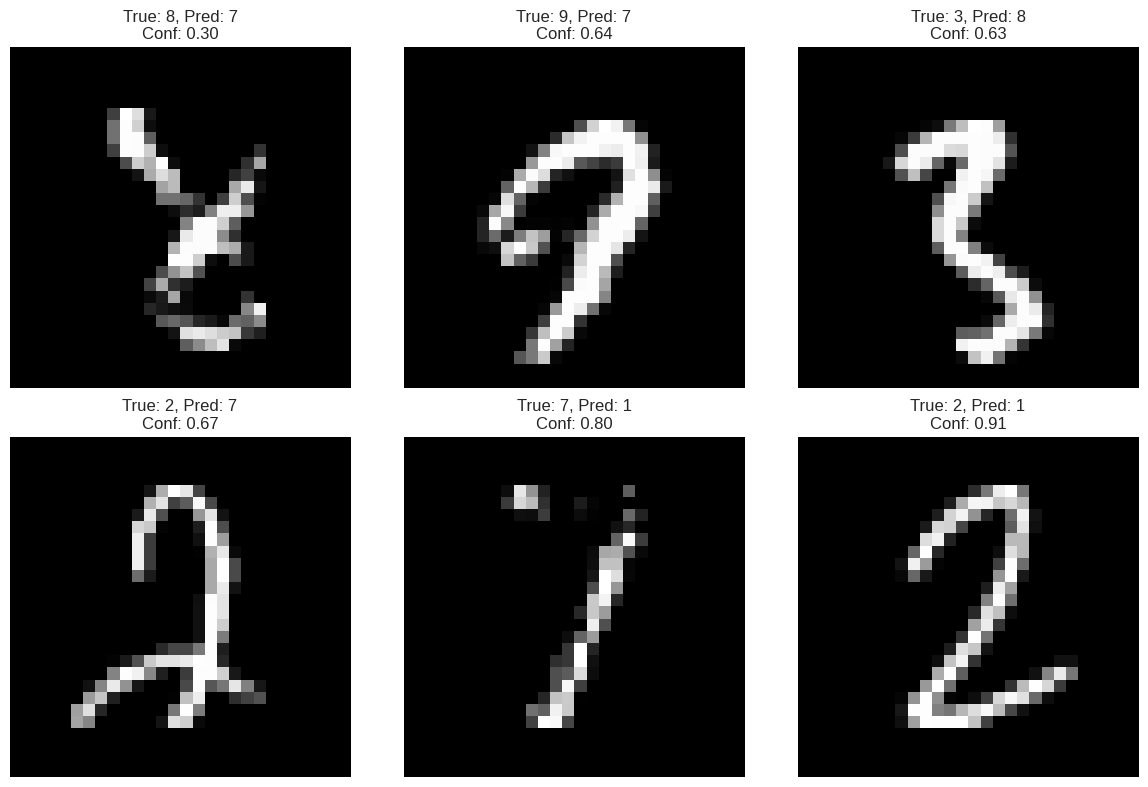

In [7]:
if model is not None:
    # Show some sample predictions
    fig, axes = plt.subplots(3, 6, figsize=(15, 9))
    axes = axes.ravel()
    
    # Select random samples
    indices = np.random.choice(len(x_test), 18, replace=False)
    
    for i, idx in enumerate(indices):
        # Reshape back to 28x28 for display
        image = x_test[idx].reshape(28, 28)
        true_label = y_test[idx]
        pred_label = y_pred[idx]
        confidence = y_pred_proba[idx, pred_label]
        
        axes[i].imshow(image, cmap='gray')
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}', 
                         color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Show some wrong predictions
    wrong_indices = np.where(y_pred != y_test)[0]
    if len(wrong_indices) > 0:
        print(f"\nShowing {min(6, len(wrong_indices))} wrong predictions:")
        
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        axes = axes.ravel()
        
        wrong_sample_indices = np.random.choice(wrong_indices, min(6, len(wrong_indices)), replace=False)
        
        for i, idx in enumerate(wrong_sample_indices):
            image = x_test[idx].reshape(28, 28)
            true_label = y_test[idx]
            pred_label = y_pred[idx]
            confidence = y_pred_proba[idx, pred_label]
            
            axes[i].imshow(image, cmap='gray')
            axes[i].set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2f}')
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No wrong predictions found!")
else:
    print("No model available for predictions")

## Weight Visualization

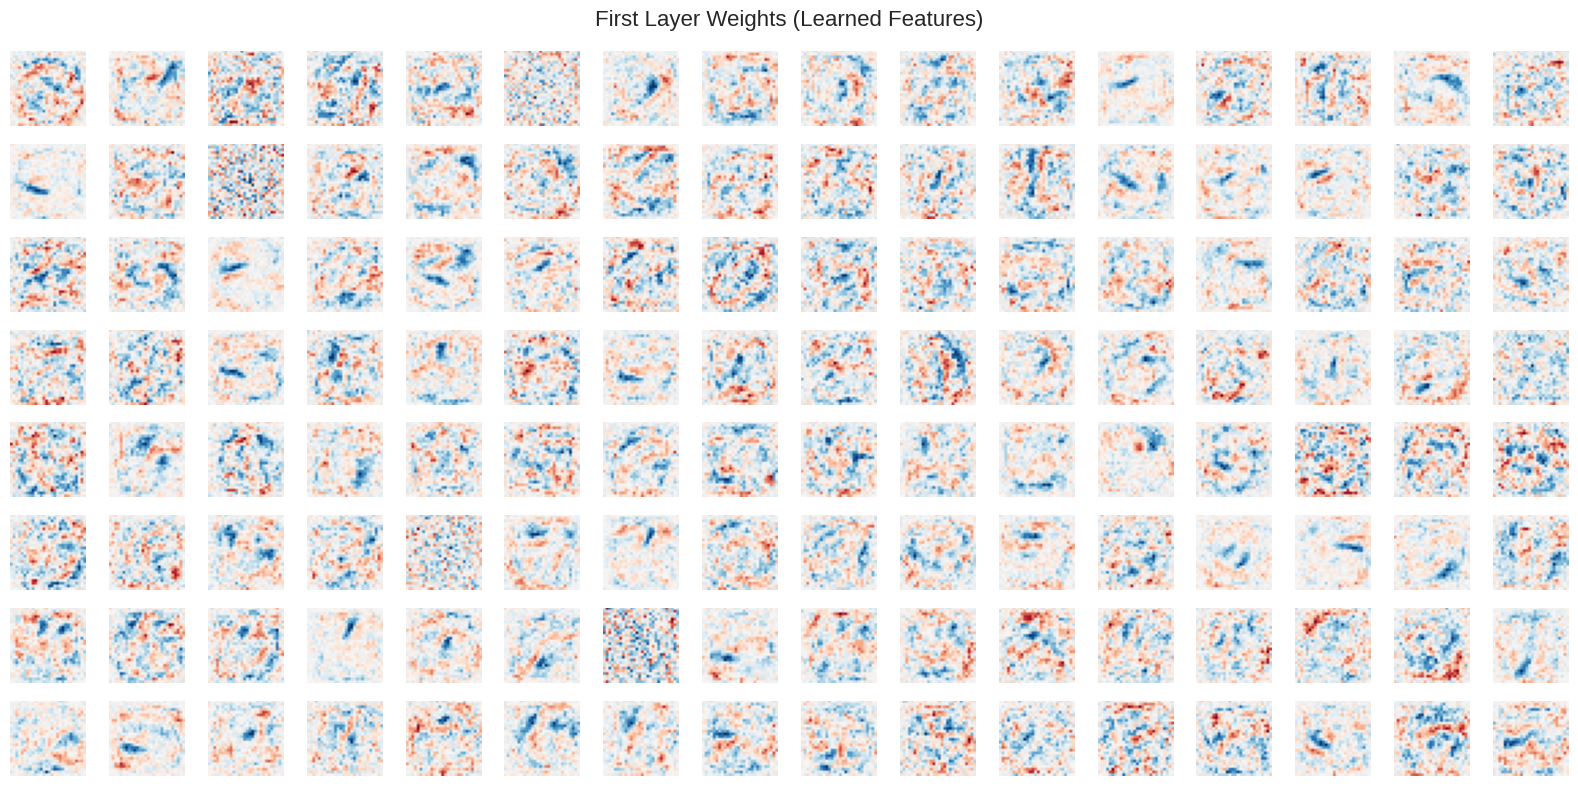

Each image shows what the neuron 'looks for' in the input.
Red = positive weights, Blue = negative weights


In [8]:
if model is not None:
    # Visualize first layer weights as images
    weights = model.get_weights()[0]['W']  # First layer weights
    
    fig, axes = plt.subplots(8, 16, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(128, len(axes))):
        # Reshape weight vector to 28x28 image
        weight_image = weights[:, i].reshape(28, 28)
        axes[i].imshow(weight_image, cmap='RdBu_r', vmin=-np.max(np.abs(weight_image)), 
                      vmax=np.max(np.abs(weight_image)))
        axes[i].axis('off')
    
    plt.suptitle('First Layer Weights (Learned Features)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print("Each image shows what the neuron 'looks for' in the input.")
    print("Red = positive weights, Blue = negative weights")
else:
    print("No model available for weight visualization")